# Hough Lines and circles


We start by importing the necessary packages:

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.cm as cm

We'll now load in the image checkers.jpg and display it.

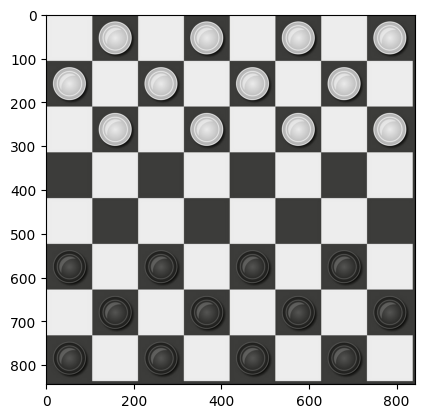

In [9]:
path = "C:/Users/peisz/OneDrive/Documents/Egyetem/DTU/3rd semester/PAS/Week 2/"

img = cv2.imread(path + 'checkers.png')
# Changing the order from bgr to rgb so that matplotlib can show it
# OpenCV defaults to BGR, but Matplotlib uses RGB. We must rearrange the channels
# otherwise the colors will look inverted (blue will look red, etc).
b,g,r = cv2.split(img)
img = cv2.merge([r,g,b])
plt.imshow(img)

## Detecting lines using `cv2.HoughLines`
First we would like to detect the lines in the image using Hough Lines. OpenCV has a function to do this, called [`cv2.HoughLines`](https://docs.opencv.org/4.7.0/dd/d1a/group__imgproc__feature.html#ga46b4e588934f6c8dfd509cc6e0e4545a) (Click to see the documentation). It is found that this function takes a 1-channel image as input, i.e. a grayscale image. The image is already in black and white, but it has been loaded as a rgb image, so we still need to convert it:

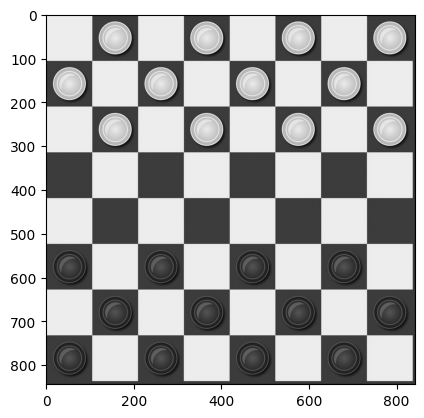

In [3]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.imshow(gray, cmap=cm.gray)

Next, we use the edge detection [`cv2.Canny`](https://docs.opencv.org/4.7.0/dd/d1a/group__imgproc__feature.html#ga04723e007ed888ddf11d9ba04e2232de) to make it easier to locate the lines. Recall the previous exercise where we used the same function and played around with the threshold.

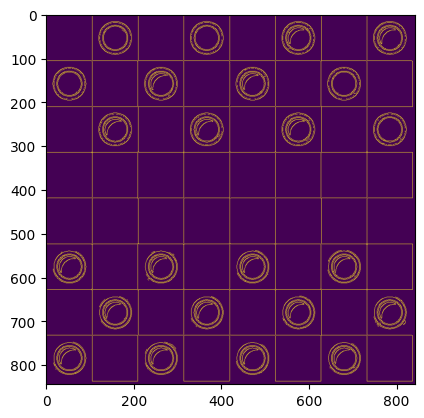

In [10]:
# Apply Canny edge detection
# We use a lower threshold of 20 and a higher threshold of 200.
# The large gap between thresholds allows for hysteresis: strong edges (above 200) are kept,
# and weak edges (between 20 and 200) are only kept if they are connected to strong edges.
edges = cv2.Canny(gray, 20, 200)
plt.imshow(edges)

You might notice (but not necessarily) that many of the lines aren't found by the edge detector. In this case, it is because the picture is resized to fit the output cell. If you have the full image, the lines should show up nicely.

Now we can use the `cv2.HoughLines` function. From the documentation it is seen that it returns a vector of 
lines. As parameters, the function takes the grayscale image (`edges`), the resolution of the radius `rho` in pixels (we choose 1), the resolution of the angle `theta` in radians (we choose 1 radian) and the minimum number of intersections to detect a line (we choose 200).

In [11]:
# cv2.HoughLines(image, rho, theta, threshold)
# image: binary edge map (from Canny).
# rho: Distance resolution of the accumulator in pixels. We use 1 pixel.
# theta: Angle resolution of the accumulator in radians. We use 1 degree (pi/180).
# threshold: Accumulator threshold parameter. Only those lines are returned that get enough votes (> 200).
# The function returns an array of (rho, theta) values.
lines = cv2.HoughLines(edges, 1, np.pi/180, 200) 

The lines are given in polar coordinates, so we will now convert them to cartesian coordinates in order to show them in the image. Numpy has its own $\cos$ and $\sin$ functions. We make a loop that goes through every line, converts the polar coordinates to cartesian coordinates and draws the corresponding line in the original image.

In [12]:
for i in range(len(lines)):
    # Extract rho and theta for the current line
    r = lines[i][0][0]     # Distance from coordinate origin to the line
    theta = lines[i][0][1] # Angle of the line normal
    
    # Convert polar coordinates to Cartesian coordinates to find a reference point (x0, y0) on the line
    # x0 = r * cos(theta)
    # y0 = r * sin(theta)
    x0 = r * np.cos(theta)
    y0 = r * np.sin(theta)
    
    # We need two points to draw a line. Since we have a point on the line (x0, y0) and the angle,
    # we can find two other points far away in both directions to simulate an infinite line.
    # We move 1000 pixels in one direction (-sin(theta), cos(theta)) and 1000 pixels in the opposite.
    # The direction vector is perpendicular to the normal vector (cos(theta), sin(theta)).
    pt1 = (int(x0 + 1000 * (-np.sin(theta))), int(y0 + 1000 * np.cos(theta)))
    pt2 = (int(x0 - 1000 * (-np.sin(theta))), int(y0 - 1000 * np.cos(theta)))
    
    cv2.line(img, pt1, pt2, (255, 0, 0), 3)

Finally, we can show the image:

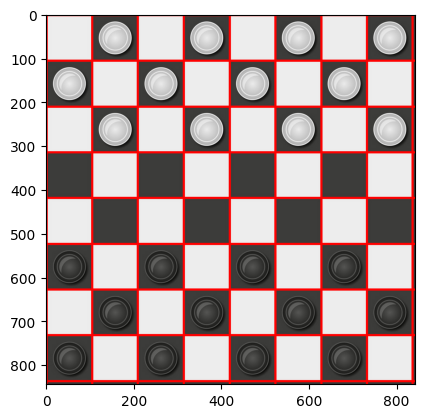

In [7]:
plt.imshow(img)

We can see that we have found all the lines of the checkerboard!


## Exercise 1
For the same checkerboard image, detect the checkerboard pieces using the OpenCV function [`cv2.HoughCirles`](https://docs.opencv.org/4.7.0/dd/d1a/group__imgproc__feature.html#ga47849c3be0d0406ad3ca45db65a25d2d). Try to find all the pieces and no false circles, by tweaking the different parameters. 

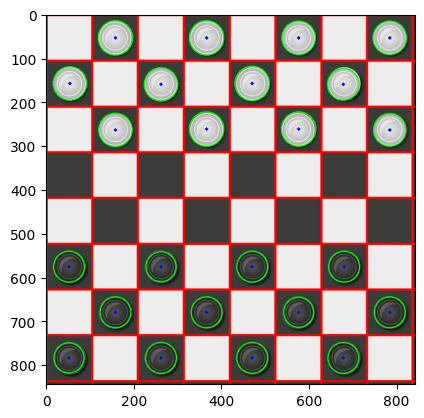

In [15]:
img2 = img.copy()

# cv2.HoughCircles(image, method, dp, minDist, param1, param2, minRadius, maxRadius)
# image: 8-bit, single-channel, grayscale input image.
# method: Detection method, currently only cv2.HOUGH_GRADIENT is available.
# dp: Inverse ratio of the accumulator resolution to the image resolution. 1 = same resolution.
# minDist: Minimum distance between the centers of the detected circles. If too small, multiple neighbor circles may be falsely detected.
# param1: Higher threshold for the Canny edge detector (passed internally to Canny).
# param2: Accumulator threshold for the circle centers at the detection stage. The smaller it is, the more false circles may be detected.
# minRadius/maxRadius: Limits for the circle size.
circles = cv2.HoughCircles(edges, cv2.HOUGH_GRADIENT, 1, 20,
                           param1=50, param2=30, minRadius=30, maxRadius=70)

# Round the circle parameters (x, y, radius) to the nearest integers so we can draw them
circles = np.uint16(np.around(circles))

for i in circles[0,:]:
    # draw the outer circle (green)
    # i[0] = x center, i[1] = y center, i[2] = radius
    cv2.circle(img2, (i[0], i[1]), i[2], (0, 255, 0), 2)
    
    # draw the center of the circle (red)
    # radius is hardcoded to 2 for a small dot
    cv2.circle(img2, (i[0], i[1]), 2, (0, 0, 255), 3)

plt.imshow(img2)